<div style="
background: linear-gradient(135deg, #fceff9, #e0f7fa);
padding:45px;
border-radius:20px;
text-align:center;
border:1px solid #e0e0e0;
font-family:Arial, sans-serif;
box-shadow:0px 4px 15px rgba(0,0,0,0.08);
max-width:1800px;
margin:auto;
">

<h1 style="color:#6a5acd; font-size:42px; margin-bottom:10px;">
📊 Análisis Exploratorio de Datos (EDA)
</h1>

<h3 style="color:#8e7cc3; margin-top:0;">
Predicción del Diagnóstico de Diabetes
</h3>

<hr style="border:none;height:2px;background:#d1c4e9;margin:25px 0;">

<p style="font-size:18px;color:#444;">
🩺 Comprensión del Dataset Clínico<br>
📈 Análisis Estadístico y Visualización<br>
🧹 Preparación y Limpieza de Datos
</p>

<div style="
background-color:#ffffff;
border-radius:12px;
padding:15px;
margin-top:20px;
display:inline-block;
">

<p style="color:#666; font-size:15px; margin:5px;">
Proyecto de Machine Learning
</p>

<p style="color:#888; font-size:14px; margin:5px;">
✨ El análisis exploratorio permite transformar datos en conocimiento.
</p>

</div>

</div>

Prediciendo la diabetes
Este conjunto de datos proviene originalmente del Instituto Nacional de Diabetes y Enfermedades Digestivas y Renales. El objetivo es predecir en base a medidas diagnósticas si un paciente tiene o no diabetes.

Paso 1: Carga del conjunto de datos
El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre diabetes.csv. Puedes cargarlo en el código directamente desde el siguiente enlace:

https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv
O descargarlo y añadirlo a mano en tu repositorio. En este conjunto de datos encontrarás las siguientes variables:

- Pregnancies. Número de embarazos del paciente (numérico)
- Glucose. Concentración de glucosa en plasma a las 2 horas de un test de tolerancia oral a la glucosa (numérico)
- BloodPressure. Presión arterial diastólica (medida en mm Hg) (numérico)
- SkinThickness. Grosor del pliegue cutáneo del tríceps (medida en mm) (numérico)
- Insulin. Insulina sérica de 2 horas (medida en mu U/ml) (numérico)
- BMI. Índice de masa corporal (numérico)
- DiabetesPedigreeFunction. Función de pedigrí de diabetes (numérico)
- Age. Edad del paciente (numérico)
- Outcome. Variable de clase (0 o 1), siendo 0 negativo en diabetes y 1, positivo (numérico)
Paso 2: Realiza un EDA completo
Este segundo paso es vital para asegurar que nos quedamos con las variables estrictamente necesarias y eliminamos las que no son relevantes o no aportan información. Utiliza el Notebook de ejemplo que trabajamos y adáptalo a este caso de uso.

Asegúrate de dividir convenientemente el conjunto de datos en train y test como hemos visto en lecciones anteriores.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [3]:
total_data = pd.read_csv("../data/raw/diabetes.csv")

In [4]:
total_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
total_data.shape

(768, 9)

In [6]:
total_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
total_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


El conjunto de datos contiene variables numéricas relacionadas con mediciones clínicas utilizadas para el diagnóstico de diabetes. Se identificó que la variable objetivo es Outcome, la cual clasifica a los pacientes entre diabéticos y no diabéticos. La estructura del dataset es adecuada para aplicar técnicas de aprendizaje supervisado.

In [9]:
total_data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [10]:
(total_data[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] == 0).sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

In [11]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

total_data[cols] = total_data[cols].replace(0, np.nan)

In [12]:
total_data.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [13]:
total_data.fillna(total_data.median(), inplace=True)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,1


Aunque el dataset no presenta valores nulos explícitos, se identificaron valores iguales a cero en variables clínicas donde fisiológicamente no son posibles. Estos valores fueron tratados como datos faltantes y reemplazados mediante imputación usando la mediana para preservar la distribución original de los datos.

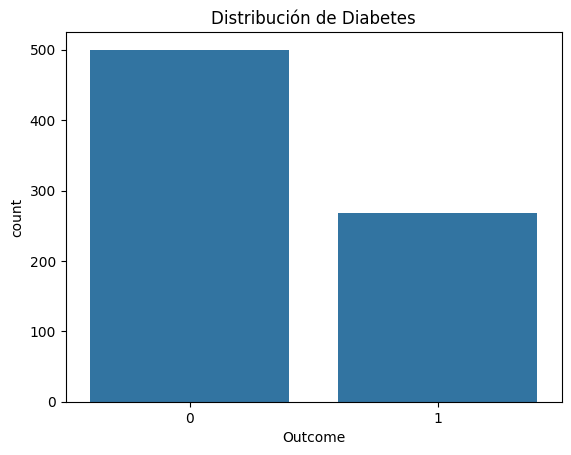

In [16]:
sns.countplot(x="Outcome", data=total_data)
plt.title("Distribución de Diabetes")
plt.show()

El análisis de la variable Outcome mostró un ligero desbalance entre pacientes diagnosticados con diabetes y pacientes sanos. Este aspecto deberá considerarse durante el entrenamiento del modelo, ya que puede influir en el desempeño predictivo.

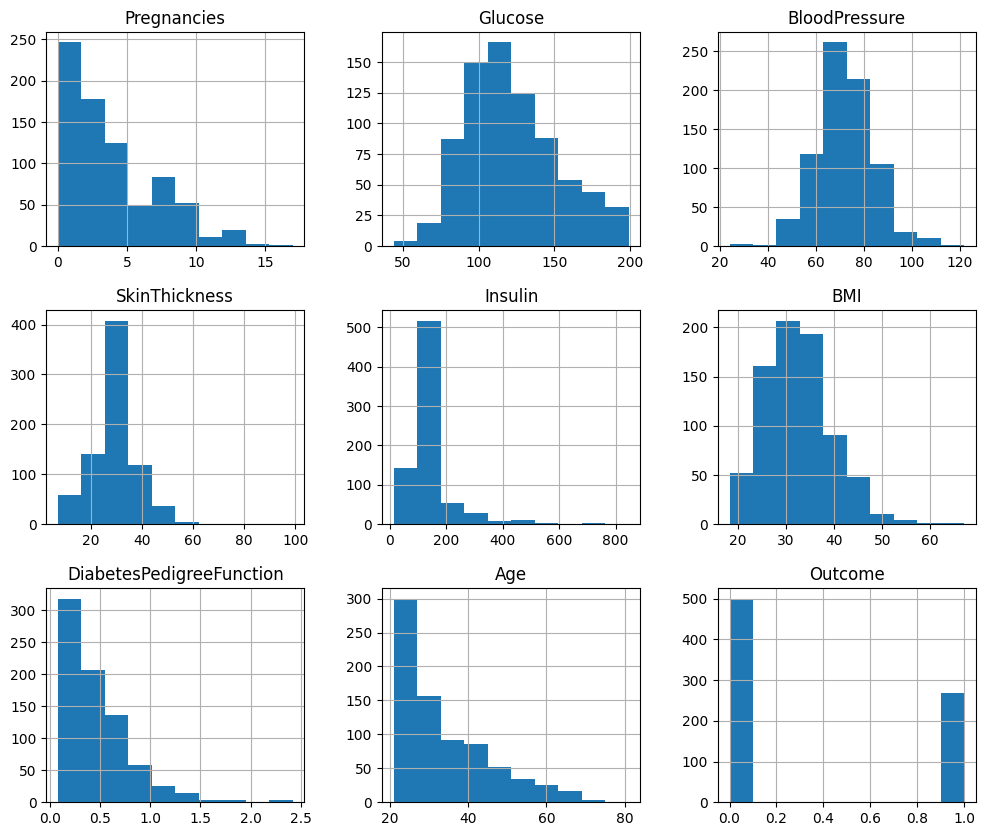

In [17]:
total_data.hist(figsize=(12,10))
plt.show()

Las distribuciones evidencian que algunas variables presentan asimetría y dispersión elevada, particularmente la insulina y la glucosa. Asi mismo se evidencia que la variable Age se encuentra concentrada en adultos jóvenes. Estas características reflejan la variabilidad natural de los indicadores médicos dentro de la población estudiada.

### Glucosa - Diabetes

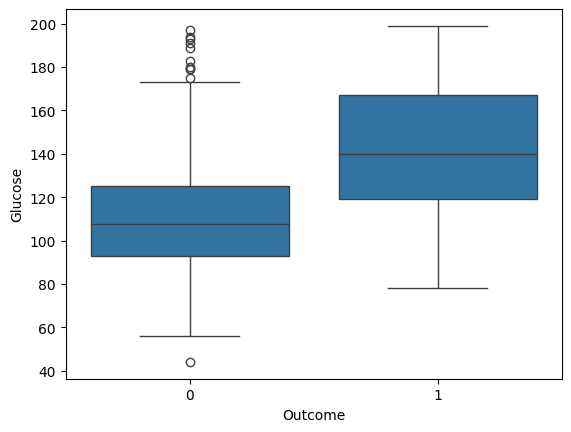

In [18]:
sns.boxplot(x="Outcome", y="Glucose", data=total_data)
plt.show()

Pacientes diabéticos tienen glucosa claramente mayor

### BMI - Diabetes

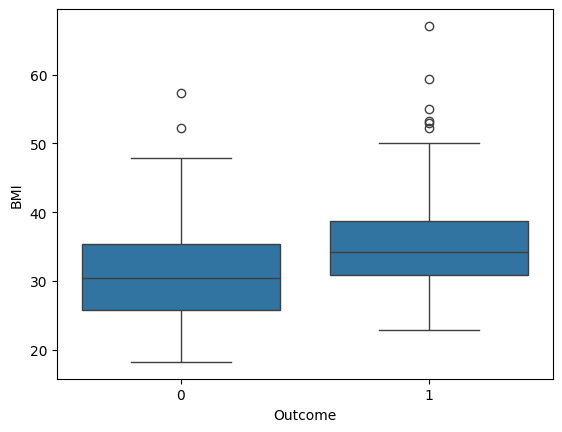

In [19]:
sns.boxplot(x="Outcome", y="BMI", data=total_data)
plt.show()

Mayor IMC asociado a diabetes.

### Edad - Diabetes

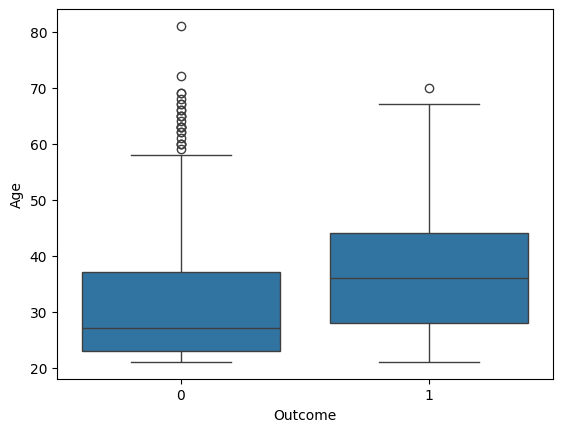

In [21]:
sns.boxplot(x="Outcome", y="Age", data=total_data)
plt.show()

Riesgo aumenta con la edad

### Embarazos - Diabetes

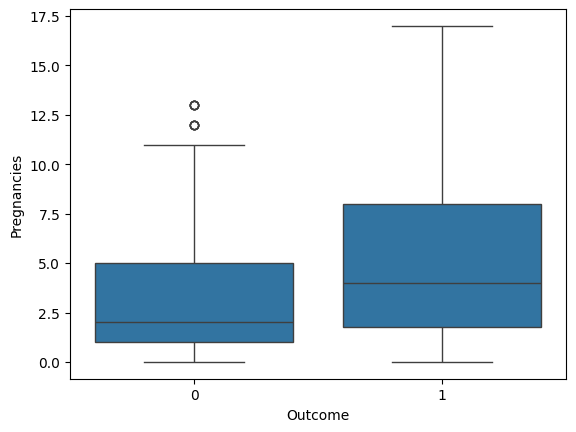

In [23]:
sns.boxplot(x="Outcome", y="Pregnancies", data=total_data)
plt.show()

Más embarazos → mayor probabilidad

El análisis comparativo entre pacientes diabéticos y no diabéticos permitió identificar diferencias claras en variables como Glucose, BMI, Age y Pregnancies. Los pacientes diagnosticados con diabetes tienden a presentar mayores niveles de glucosa, mayor índice de masa corporal y mayor edad, lo cual confirma patrones clínicos conocidos.

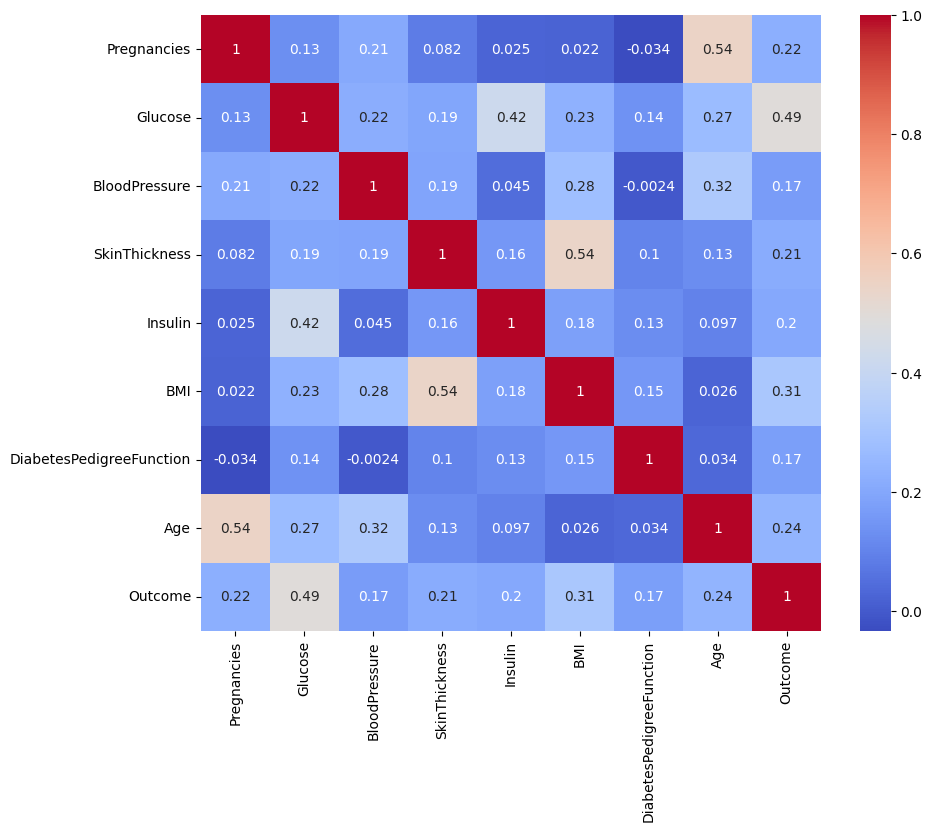

In [24]:
plt.figure(figsize=(10,8))
sns.heatmap(total_data.corr(), annot=True, cmap="coolwarm")
plt.show()

La matriz de correlación evidenció que la variable Glucose posee la mayor relación con el diagnóstico de diabetes, seguida por BMI, Age y Pregnancies. Algunas variables muestran baja correlación individual, aunque podrían aportar información combinada dentro del modelo predictivo.

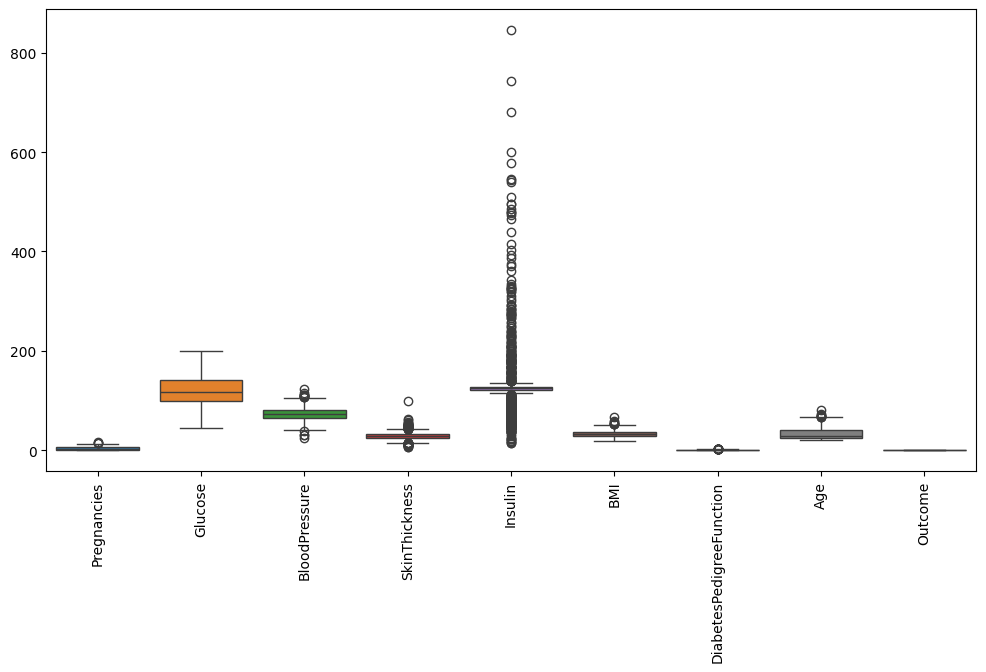

In [25]:
plt.figure(figsize=(12,6))
sns.boxplot(data=total_data)
plt.xticks(rotation=90)
plt.show()

Se identificaron valores atípicos principalmente en las variables Insulin y BMI. No obstante, estos fueron conservados debido a que pueden representar condiciones médicas reales y eliminarlos podría reducir la capacidad predictiva del modelo

In [26]:
X = total_data.drop("Outcome", axis=1)
y = total_data["Outcome"]

In [27]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33


In [28]:
y.head()

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [30]:
X_train.to_csv("../data/processed/X_train_diabetes.csv", index=False)
X_test.to_csv("../data/processed/X_test_diabetes.csv", index=False)

y_train.to_csv("../data/processed/y_train_diabetes.csv", index=False)
y_test.to_csv("../data/processed/y_test_diabetes.csv", index=False)

<div style="
background: linear-gradient(135deg,#FFF6FB,#F3F8FF);
border-radius:18px;
padding:28px;
font-family:Arial, sans-serif;
box-shadow:0px 4px 12px rgba(0,0,0,0.08);
max-width:1200px;
margin:auto;
color:#4A4A4A;
border:1px solid #E6ECF5;
">

<h3 style="color:#8FAADC;">🌸 Conclusión del análisis exploratorio</h3>

<p>
El análisis exploratorio permitió comprender las características clínicas asociadas al diagnóstico de diabetes y preparar adecuadamente los datos para el modelado predictivo.
</p>

<ul style="line-height:1.7;">
<li>El conjunto de datos no presentaba valores nulos explícitos; sin embargo, se identificaron valores iguales a cero en variables médicas críticas, los cuales fueron tratados como valores faltantes e imputados mediante la mediana.</li>

<li>Se evidenció un ligero desbalance en la variable objetivo, predominando los pacientes sin diabetes, situación que deberá considerarse durante la fase de entrenamiento del modelo.</li>

<li>La variable <b style="color:#A58FD6;">Glucose</b> mostró la mayor relación con el diagnóstico de diabetes, confirmando su relevancia clínica como principal indicador metabólico.</li>

<li>El índice de masa corporal (<b style="color:#F4A7B9;">BMI</b>), la edad (<b style="color:#F4A7B9;">Age</b>) y el número de embarazos (<b style="color:#F4A7B9;">Pregnancies</b>) también demostraron una asociación positiva con la enfermedad.</li>

<li>Algunas variables como <b style="color:#7FB3D5;">BloodPressure</b> y <b style="color:#7FB3D5;">SkinThickness</b> presentan menor capacidad predictiva individual.</li>

<li>Se detectaron valores atípicos, especialmente en niveles de insulina; sin embargo, fueron conservados al representar posibles condiciones médicas reales.</li>

<li>Finalmente, el dataset fue dividido correctamente en conjuntos de entrenamiento y prueba utilizando estratificación, garantizando una evaluación objetiva del rendimiento del modelo.</li>
</ul>

<p>
✨ Tras el EDA, los datos quedan listos para aplicar técnicas de escalado, entrenamiento de modelos de clasificación y evaluación del desempeño predictivo para la detección temprana de diabetes.
</p>

</div>